## Exercise 4
### Hydrogen Burning

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt

For an easy access to the cross sections we import another package. With this package it is possible to read reaclib files and to get the cross sections at a specific temperature.  

In [ ]:
from class_files.reaclib_class import reaclib

# For this, we have to give the path of the Reaclib file
r = reaclib("hburning_reactions.dat")
r.read_reaclib()
import warnings
warnings.filterwarnings('ignore')

ImportError: cannot import name 'reaclib' from 'pynucastro' (c:\Users\Max\anaconda3\lib\site-packages\pynucastro\__init__.py)

In [3]:
# With the class we can now access all reactions that are contained in the Reaclib
# For this we have to call the function "get_rate_at_temp", followed by the temperature in GK, 
# the reactants as a list, and the products as a list. The return value will be Avogadros number (NA)
# times the cross section at the given temperature.
# For example, we can access <ov>_pp * NA at 0.015 GK by:
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])

In [18]:
# Run winnet
! /home/teaching/WinNet/bin/winnet Hydrogen_burning.par >OUT 2>ERR

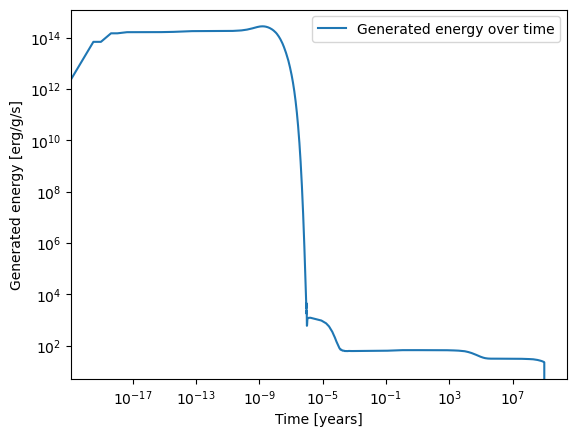

In [20]:
data = np.loadtxt("generated_energyT0.015GK.dat", skiprows=1)

time = data[:, 0]
totalenergy = data[:, 1]

plt.plot(time / (365*24*3600), totalenergy, label="Generated energy over time")
plt.xlabel('Time [years]')
plt.ylabel('Generated energy [erg/g/s]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

We can observe that the generated energy increased in the first few moments and then remains more or less constant over a long time period. After that it experiences two dip at around 1e-5 years, one being pretty sharp and the other one being more soft. In the end, the generated energy is somewhat constant again until it reaches zero at the end of the time interval.

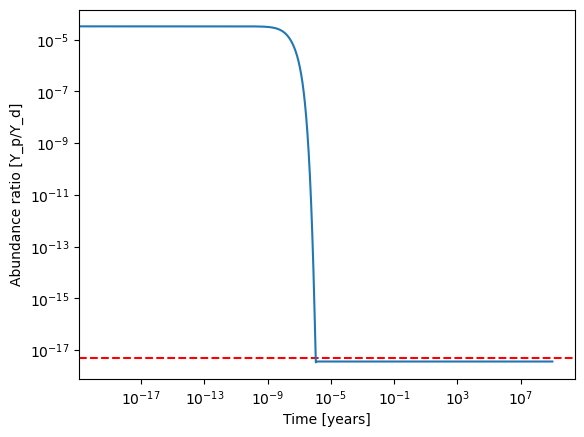

In [40]:
trackT1 = np.loadtxt("tracked_nucleiT0.015GK.dat", skiprows=1)

timeT1 = trackT1[:, 0] 
Y_p = trackT1[:, 1] 
Y_d = trackT1[:, 2] 
Y_he3 = trackT1[:, 3] 
Y_he4 = trackT1[:, 4]

'''Looking up the reaction rates at JINA, because I dont know the module class_files.reaclib_class...'''
R_pp = 1e-19
R_pd = 1e-2
plt.axhline(R_pp/(2*R_pd), color='red', linestyle='--')
plt.plot(time / (365*24*3600), Y_d / Y_p)
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_p/Y_d]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

In [36]:
eqtime = 1e-6 * 365 * 24 * 60 * 60
eqtime

31.536000000000005

It takes about 1e-6 years to reach equilibrium, which is about 32 seconds. This is not comparable to the scale of the lifetime of a star. 

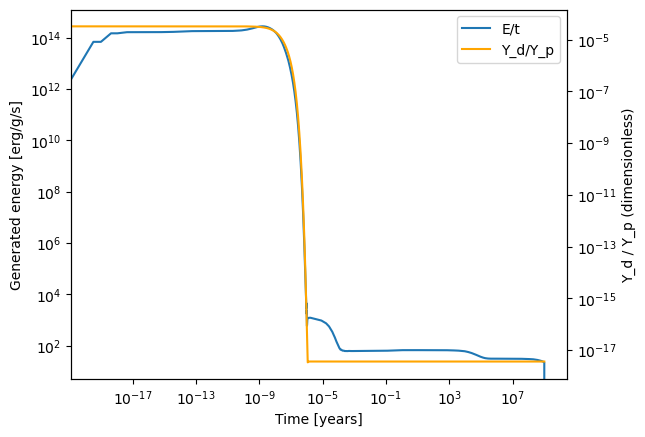

In [68]:
fig, ax1 = plt.subplots()

ax1.plot(time / (365*24*3600), totalenergy, label="E/t")
ax1.set_xlabel('Time [years]')
ax1.set_ylabel('Generated energy [erg/g/s]')
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(timeT1 / (365*24*3600), Y_d / Y_p, color='orange', label="Y_d/Y_p")
ax2.set_ylabel('Y_d / Y_p (dimensionless)')
ax2.set_yscale('log')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()

We can see a very similar behavior of the generated energy and deuterium ration over time, especially when both graph decrease. I think it is possible to measure primordial deuterium abundances, because even with sloppy approximations we can see significantly similar results in both graphs, which points to promising data of deuterium abundance.

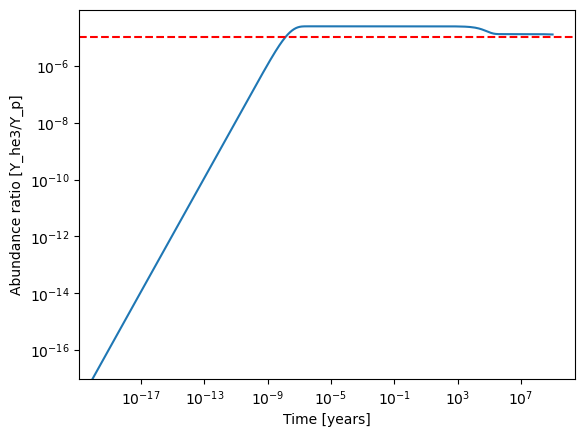

In [67]:

'''Looking up the reaction rates at JINA, because I dont know the module class_files.reaclib_class...'''
R_pp = 1e-19
R_he3he3 = 0.5*1e-9

ratio_rate = np.sqrt(R_pp / (2*R_he3he3))
plt.plot(time / (365*24*3600), Y_he3 / Y_p)
plt.axhline(ratio_rate, color='red', linestyle = '--')
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_he3/Y_p]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

In [50]:
timeeqhe3 = 1e-8 * 365 * 24 * 3600
timeeqhe3

0.31536000000000003

It takes about 1/3 of a second to reach the equilibrium. This little overshoot above the equilibrium value could be due to the fact that at this point in time the equlibrium of deuterium is reached and the system suddenly gets enough energy again to create more he3.

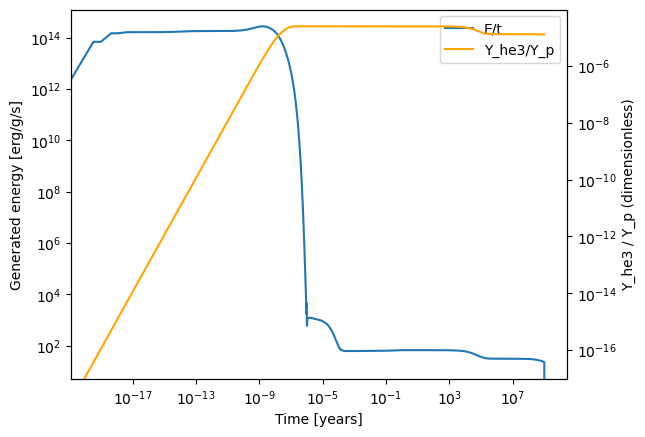

In [69]:
fig, ax1 = plt.subplots()

ax1.plot(time / (365*24*3600), totalenergy, label="E/t")
ax1.set_xlabel('Time [years]')
ax1.set_ylabel('Generated energy [erg/g/s]')
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(timeT1 / (365*24*3600), Y_he3 / Y_p, color='orange', label="Y_he3/Y_p")
ax2.set_ylabel('Y_he3 / Y_p (dimensionless)')
ax2.set_yscale('log')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()

As we can see in the figure above, the point in time where the second dip in the generated energy is and the overshoot of he3 abundance intersects, which underlines the previous statement.

In [72]:
len(Y_he3)

527

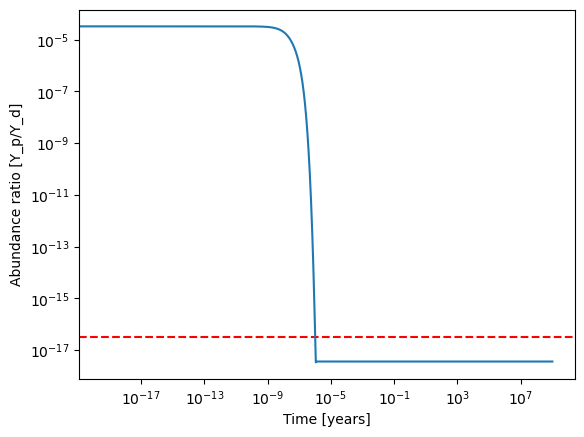

In [77]:
Y_p_equi = 0.751
Q_pp = 1.44
Q_dp = 5.49
Q_he3 = 12.9
Y_he3_equi = Y_he3[len(Y_he3)-1]
Y_d_equi = Y_d[len(Y_d)-1]
rho = 100

epsilon = 0.5 * rho * Y_p_equi**2 * R_pp * Q_pp + 0.5 * rho * Y_he3_equi**2 *R_he3he3*Q_he3 + rho * Y_d_equi * Y_p_equi * R_pd * Q_dp

plt.axhline(epsilon, color='red', linestyle='--', label='equilibrium')
plt.plot(time / (365*24*3600), Y_d / Y_p)
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_p/Y_d]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

The red dashed equilibrium value is way off (logarithmic scale) the value of the WINNET calculated value at the end of the time
interval.

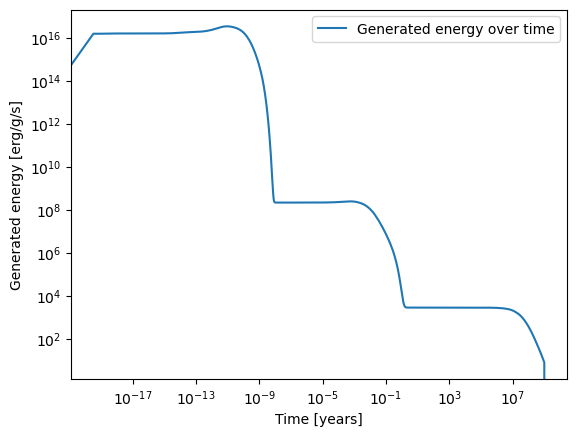

In [78]:
data2 = np.loadtxt("generated_energyT0.05GK.dat", skiprows=1)

time = data2[:, 0]
totalenergy = data2[:, 1]

plt.plot(time / (365*24*3600), totalenergy, label="Generated energy over time")
plt.xlabel('Time [years]')
plt.ylabel('Generated energy [erg/g/s]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

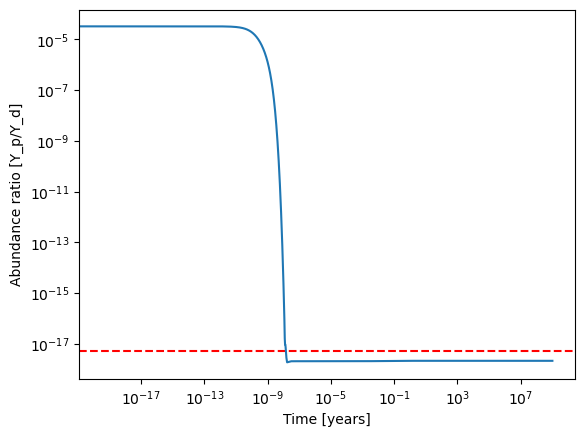

In [81]:
trackT2 = np.loadtxt("tracked_nucleiT0.05GK.dat", skiprows=1)

time = trackT2[:, 0] 
Y_p = trackT2[:, 1] 
Y_d = trackT2[:, 2] 
Y_he3 = trackT2[:, 3] 
Y_he4 = trackT2[:, 4]

'''Looking up the reaction rates at JINA, because I dont know the module class_files.reaclib_class...'''
R_pp = 1e-19
R_pd = 1e-2
plt.axhline(R_pp/(2*R_pd), color='red', linestyle='--')
plt.plot(time / (365*24*3600), Y_d / Y_p)
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_p/Y_d]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

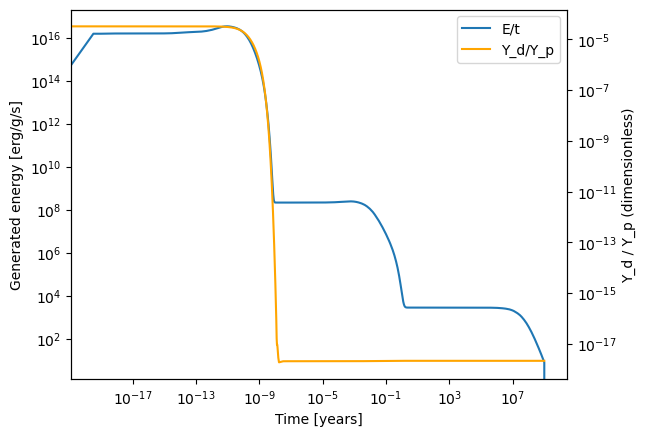

In [82]:
fig, ax1 = plt.subplots()

ax1.plot(time / (365*24*3600), totalenergy, label="E/t")
ax1.set_xlabel('Time [years]')
ax1.set_ylabel('Generated energy [erg/g/s]')
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(timeT1 / (365*24*3600), Y_d / Y_p, color='orange', label="Y_d/Y_p")
ax2.set_ylabel('Y_d / Y_p (dimensionless)')
ax2.set_yscale('log')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()

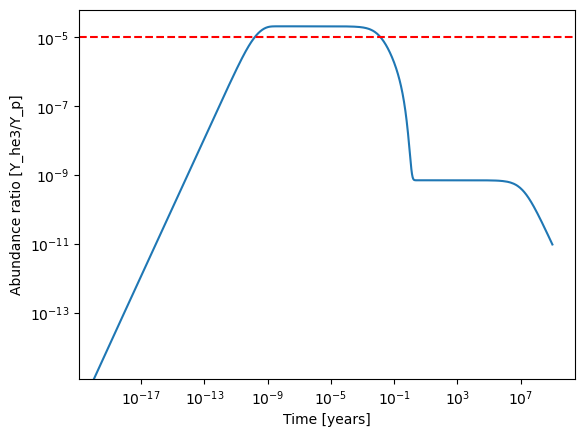

In [83]:

'''Looking up the reaction rates at JINA, because I dont know the module class_files.reaclib_class...'''
R_pp = 1e-19
R_he3he3 = 0.5*1e-9

ratio_rate = np.sqrt(R_pp / (2*R_he3he3))
plt.plot(time / (365*24*3600), Y_he3 / Y_p)
plt.axhline(ratio_rate, color='red', linestyle = '--')
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_he3/Y_p]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

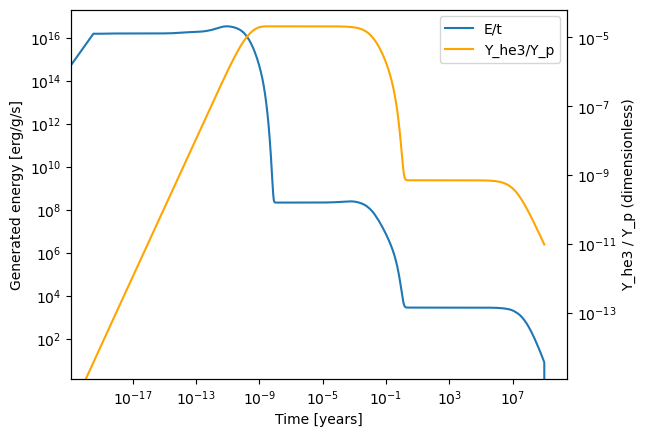

In [84]:
fig, ax1 = plt.subplots()

ax1.plot(time / (365*24*3600), totalenergy, label="E/t")
ax1.set_xlabel('Time [years]')
ax1.set_ylabel('Generated energy [erg/g/s]')
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(timeT1 / (365*24*3600), Y_he3 / Y_p, color='orange', label="Y_he3/Y_p")
ax2.set_ylabel('Y_he3 / Y_p (dimensionless)')
ax2.set_yscale('log')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()

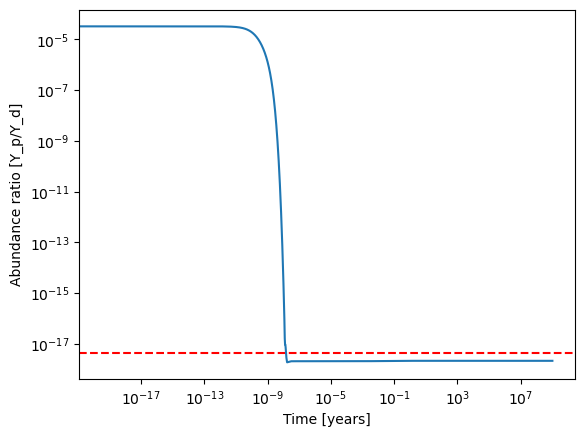

In [85]:
Y_p_equi = 0.751
Q_pp = 1.44
Q_dp = 5.49
Q_he3 = 12.9
Y_he3_equi = Y_he3[len(Y_he3)-1]
Y_d_equi = Y_d[len(Y_d)-1]
rho = 100

epsilon = 0.5 * rho * Y_p_equi**2 * R_pp * Q_pp + 0.5 * rho * Y_he3_equi**2 *R_he3he3*Q_he3 + rho * Y_d_equi * Y_p_equi * R_pd * Q_dp

plt.axhline(epsilon, color='red', linestyle='--', label='equilibrium')
plt.plot(time / (365*24*3600), Y_d / Y_p)
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_p/Y_d]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

The estimated energy generation in equilibrium is better than before, but not quite exact. The reason for that could be the poorly extracted reactions rates via JINA or the fact that WINNET uses fully temperature dependent reactions rates.